# IBM Applied Data Science Capstone
## Falcon 9 landing prediction - machine learning comparison

**Learner:** Djessi Jorge  
**Completed:** 4 August 2026

Four classifiers are tuned with ten-fold cross-validation and evaluated once on the same
18-record holdout set. The split uses `test_size=0.2` and `random_state=2` for reproducibility.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

data = pd.read_csv("dataset_part_2.csv")
feature_frame = pd.read_csv("dataset_part_3.csv")
target = data["Class"].to_numpy()
print(f"Targets: {target.shape} | Features: {feature_frame.shape}")

Targets: (90,) | Features: (90, 80)


In [2]:
scaler = StandardScaler()
features = scaler.fit_transform(feature_frame)

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=2
)

print(f"Training records: {len(y_train)}")
print(f"Test records: {len(y_test)}")
print(f"Test successes: {int(y_test.sum())} | Test failures: {int((1-y_test).sum())}")

Training records: 72
Test records: 18
Test successes: 12 | Test failures: 6


In [3]:
model_spaces = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000),
        {"C": [0.01, 0.1, 1], "solver": ["lbfgs"]},
    ),
    "SVM": (
        SVC(),
        {
            "kernel": ["linear", "rbf", "poly", "sigmoid"],
            "C": [0.001, 0.0316, 1, 31.6, 1000],
            "gamma": [0.001, 0.0316, 1, 31.6, 1000],
        },
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=2),
        {
            "criterion": ["gini", "entropy"],
            "splitter": ["best", "random"],
            "max_depth": [2, 4, 6, 8, 10, 12, 14, 16, 18],
            "max_features": ["sqrt", "log2", None],
            "min_samples_leaf": [1, 2, 4],
            "min_samples_split": [2, 5, 10],
        },
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": list(range(1, 11)),
            "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
            "p": [1, 2],
        },
    ),
}

In [4]:
fitted_models = {}
rows = []

for name, (estimator, parameter_grid) in model_spaces.items():
    search = GridSearchCV(
        estimator, parameter_grid, cv=10, scoring="accuracy", n_jobs=1
    )
    search.fit(X_train, y_train)
    predictions = search.predict(X_test)
    fitted_models[name] = search
    rows.append(
        {
            "Model": name,
            "CV_accuracy": search.best_score_,
            "Test_accuracy": search.score(X_test, y_test),
            "Best_parameters": search.best_params_,
        }
    )

results = pd.DataFrame(rows).sort_values(
    ["Test_accuracy", "CV_accuracy"], ascending=False
)
results

,Model,CV_accuracy,Test_accuracy,Best_parameters
1,SVM,0.848214,0.833333,"{'C': 1, 'gamma': 0.0316, 'kernel': 'sigmoid'}"
3,KNN,0.833929,0.833333,"{'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}"
0,Logistic Regression,0.821429,0.833333,"{'C': 1, 'solver': 'lbfgs'}"
2,Decision Tree,0.858929,0.777778,"{'criterion': 'gini', 'max_depth': 4, 'max_fea..."


In [5]:
score_table = results.set_index("Model")[["CV_accuracy", "Test_accuracy"]]
(100 * score_table).round(2)

,CV_accuracy,Test_accuracy
Model,,
SVM,84.82,83.33
KNN,83.39,83.33
Logistic Regression,82.14,83.33
Decision Tree,85.89,77.78


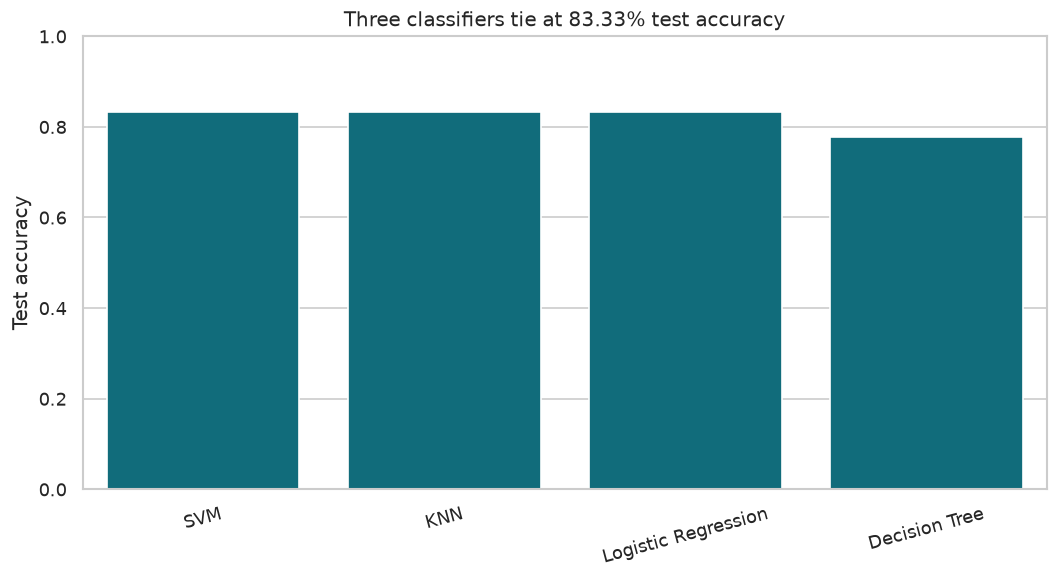

In [6]:
plt.figure(figsize=(9, 5))
ordered = results.sort_values("Test_accuracy", ascending=False)
sns.barplot(data=ordered, x="Model", y="Test_accuracy", color="#00798c")
plt.ylim(0, 1)
plt.ylabel("Test accuracy")
plt.xlabel("")
plt.title("Three classifiers tie at 83.33% test accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

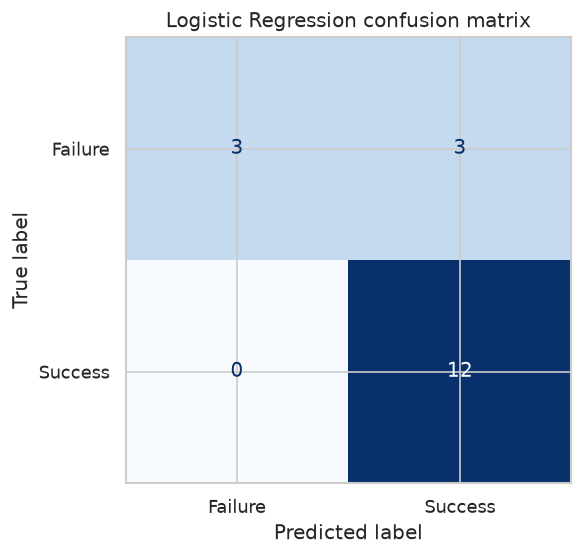

,Predicted failure,Predicted success
Actual failure,3,3
Actual success,0,12


In [7]:
logistic = fitted_models["Logistic Regression"]
logistic_predictions = logistic.predict(X_test)
matrix = confusion_matrix(y_test, logistic_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Failure", "Success"],
)
display.plot(cmap="Blues", colorbar=False)
plt.title("Logistic Regression confusion matrix")
plt.tight_layout()
plt.show()

pd.DataFrame(
    matrix,
    index=["Actual failure", "Actual success"],
    columns=["Predicted failure", "Predicted success"],
)

In [8]:
expected_scores = {
    "Logistic Regression": 15/18,
    "SVM": 15/18,
    "Decision Tree": 14/18,
    "KNN": 15/18,
}
observed = results.set_index("Model")["Test_accuracy"].to_dict()
for model, expected in expected_scores.items():
    assert np.isclose(observed[model], expected)
assert matrix.tolist() == [[3, 3], [0, 12]]

print("Validation passed: model scores and confusion matrix match the capstone report.")

Validation passed: model scores and confusion matrix match the capstone report.


### Model selection and conclusion

Logistic Regression, SVM and KNN each classify 15 of 18 holdout records correctly
(**83.33%**); the Decision Tree classifies 14 (**77.78%**). Logistic Regression is selected
as the practical baseline because it ties for the best accuracy, produces interpretable
probabilities and captures all 12 successful test landings. Its three false positives are
the main risk: predicted recoveries that were actually failures.